<a href="https://colab.research.google.com/github/gabgarar/FERMI_HESS_Analysis/blob/main/Act2_Astrop_SNR_Galactic_Center.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Astrofísica de Altas Energías

# 1. Instanciar catálogos

In [1]:
!pip install gammapy

DOWNLOAD_DATASETS=True
if DOWNLOAD_DATASETS==True:
    !gammapy download datasets
import os
os.environ["GAMMAPY_DATA"] = "./gammapy-datasets/2.1"

from gammapy.catalog import SourceCatalog3FHL, SourceCatalogHGPS

# FERMI
fermi_cat = SourceCatalog3FHL()
print(fermi_cat.description)

# H.E.S.S.
hess_cat = SourceCatalogHGPS()
print(hess_cat.description)


INFO:gammapy.scripts.download:Downloading datasets from https://github.com/gammapy/gammapy-data/tarball/v2.1
279MB [00:12, 23.1MB/s]
INFO:gammapy.scripts.download:Extracting gammapy-datasets/2.1/datasets.tar.gz

*** You might want to declare GAMMAPY_DATA as a global env variable
export GAMMAPY_DATA=$PWD/gammapy-datasets/2.1

Or as part of your conda environment:
conda env config vars set GAMMAPY_DATA=$PWD/gammapy-datasets/2.1
conda activate gammapy-2.1

LAT third high-energy source catalog
H.E.S.S. Galactic plane survey (HGPS) source catalog


# 2. Cruzar repositorios de datos

In [2]:
from astropy import units as units
def naive_xmatch (x,y,min_distance=0.1*units.deg):
    """
    Args:
        x: lista con posiciones
        y: lista con posiciones
    Returns:
        xindex: lista de índices
        yindex: lista de índices
        dists: lista de distancias

    Devuelve los índeces de x e y que están a una distancia menor que 'min_distance' además de
    la distancia de separación. La devolución se hace en orden, esto es, el primer índice de la lista
    xindex está a una distancia menor que min_distance del primero de yindex y, éstos, están a una distancia
    que corresponde al primer elemento de la lista dists
    """
    xindex = []
    yindex = []
    dists = []
    for i in range(len(x)):
        d = x[i].separation(y)
        amin = d.argmin()
        dmin = d[amin]
        if dmin < min_distance:
            xindex.append(i)
            yindex.append(amin)
            dists.append(dmin)
    return xindex,yindex,dists


# Obtención de las posiciones.
## Crea dos variables llamadas fermi_pos y hess_pos que sean las coordenadas de los repectivos catálogos

from astropy.coordinates import SkyCoord
import astropy.units as u

fermi_pos = SkyCoord(fermi_cat.table["RAJ2000"],
                     fermi_cat.table["DEJ2000"],
                     unit=u.deg)

hess_pos = SkyCoord(hess_cat.table["RAJ2000"],
                    hess_cat.table["DEJ2000"],
                    unit=u.deg)

# rellena la siguiente celda para obtener los índices que corresponden a los mismos objetos en cada catalogo
xindex, yindex, dists = naive_xmatch(fermi_pos, hess_pos)


# 3. Escoger los datos de estudio

In [3]:
import astropy.units as u

# Creo una lista con información
matches = []

for i, j, d in zip(xindex, yindex, dists):
    deg = d.to(u.deg).value
    name = str(fermi_cat.table["Source_Name"][i])

    # clasificación básica por diversidad física
    if "1745" in name:
        typ = "Galactic Center"
    elif "1023" in name or "1119" in name or "1303" in name or "1640" in name:
        typ = "PWN"
    else:
        typ = "SNR/Other"

    matches.append((i, j, d, deg, typ))

# Ordenar por robustez (distancia creciente)
matches.sort(key=lambda x: x[3])

# Selección de 3 tipos diferentes
selected = []
types_used = set()

for m in matches:
    i, j, d, deg, typ = m

    if typ not in types_used:
        selected.append(m)
        types_used.add(typ)

    if len(selected) == 3:
        break

# impresión final
for i, j, d, deg, typ in selected:
    print("FERMI:", fermi_cat.table["Source_Name"][i])
    print("HESS:", hess_cat.table["Source_Name"][j])
    print("DIST:", d)
    print("TIPO:", typ)
    print("------")

FERMI: 3FHL J1826.2-1451 
HESS: HESS J1826-148
DIST: 0d00m21.66735381s
TIPO: SNR/Other
------
FERMI: 3FHL J1745.6-2900 
HESS: HESS J1745-290
DIST: 0d00m22.80861866s
TIPO: Galactic Center
------
FERMI: 3FHL J1303.0-6312e
HESS: HESS J1303-631
DIST: 0d00m25.19211844s
TIPO: PWN
------


# 4. Estudio por ajuste de ley de **potencias**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from gammapy.datasets import FluxPointsDataset, Datasets
import gammapy.modeling.models as gmodels
from gammapy.modeling import Fit
import pandas as pd


# ============================================================
# Ajuste de modelo (acepta dataset único o lista de datasets)
# ============================================================
def fixModel(fds_model, AmpUnits, refUnits, modelName, backend_model="minuit"):

    # Asegurar que fds_model sea una lista de datasets
    if isinstance(fds_model, list):
        joint_ds = Datasets(fds_model)
    else:
        joint_ds = Datasets([fds_model])

    # Definición del modelo espectral de Ley de Potencias
    model = gmodels.PowerLawSpectralModel(
        amplitude=AmpUnits,
        reference=refUnits
    )
    sky_model = gmodels.SkyModel(spectral_model=model, name=modelName)

    # Ajuste
    joint_ds.models = sky_model
    result = Fit(backend=backend_model).run(datasets=joint_ds)

    # Mostrar parámetros resultantes
    print("---- VALORES AJUSTADOS ----")
    print(sky_model.spectral_model.parameters.to_table()[["name", "value", "error"]])

    return sky_model, joint_ds, result



# ============================================================
# Gráfico SED
# ============================================================
def showGraph(model, fds, ebounds, xLimits, yUnits, title):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    plot_kwargs = {"ax": ax, "sed_type": "e2dnde"}

    # Unidad correcta del eje Y (no depende del eje X)
    ax.yaxis.set_units(u.Unit(yUnits))

    # Pintar puntos de datos
    fds.data.plot(label=fds.name, color="darkblue", **plot_kwargs)

    # Pintar modelo ajustado
    model.spectral_model.plot(ebounds, label=model.name, color="blue", **plot_kwargs)
    model.spectral_model.plot_error(ebounds, color="lightblue", alpha=0.4, **plot_kwargs)

    ax.set_xlim(xLimits[0], xLimits[1])
    ax.set_title(title)
    ax.legend()
    plt.show()



def showGraph_multi(model, datasets, ebounds, xLimits, yUnits, title):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    plot_kwargs = {"ax": ax, "sed_type": "e2dnde"}

    # Unidad del eje Y
    ax.yaxis.set_units(u.Unit(yUnits))

    # Pintar cada dataset con un color distinto
    colors = ["darkblue", "darkred", "darkgreen", "purple"]

    for ds, col in zip(datasets, colors):
        ds.data.plot(label=ds.name, color=col, **plot_kwargs)

    # Pintar modelo ajustado
    model.spectral_model.plot(ebounds, label=model.name, color="black", **plot_kwargs)
    model.spectral_model.plot_error(ebounds, color="gray", alpha=0.4, **plot_kwargs)

    ax.set_xlim(xLimits[0], xLimits[1])
    ax.set_title(title)
    ax.legend()
    plt.show()



# ============================================================
# Ajuste según catálogos (Fermi, HESS, etc.)
# ============================================================
def fix_model_given_catalog(catalogs, catNames, AmpUnits, refUnits, modelName, backend_mode="minuit"):

    fds_models = []

    for cat, src_name in zip(catalogs, catNames):

        # Lista de nombres del catálogo
        names_clean_catalog = np.array([str(n).strip() for n in cat.table["Source_Name"]])

        # Buscar coincidencia exacta
        matches = np.where(np.char.find(names_clean_catalog, src_name.strip()) >= 0)[0]
        if len(matches) == 0:
            raise ValueError(f"No se encontró la fuente '{src_name}' en el catálogo.")
        cat_idx = matches[0]
        print(f"Índice en {src_name}: {cat_idx}")

        # Construcción del dataset
        fds = FluxPointsDataset(data=cat[cat_idx].flux_points, name=cat[cat_idx].name)
        print(f"Dataset usado: {fds.name}")

        fds_models.append(fds)

    # Ajustar modelo conjunto
    sky_model, joint_ds, result = fixModel(fds_models, AmpUnits, refUnits, modelName, backend_mode)

    return sky_model, joint_ds, result



# ============================================================
# FUNCIÓN PARA GENERAR TABLA DE PARÁMETROS ESPECTRALES
# ============================================================
def build_spectral_table(models, ref_energies, labels):

    rows = []

    for model, refE, label in zip(models, ref_energies, labels):

        spec = model.spectral_model

        # Índice espectral
        gamma, gamma_err = spec.index.value, spec.index.error

        amp = spec.amplitude.value
        amp_err = spec.amplitude.error

        # Determine the display unit label based on the amplitude's intrinsic unit
        # and apply specific conversion for the joint model if its amplitude is in GeV but display is wanted in TeV
        display_unit_label = "Norm. (×1e-12)"
        if label == "Conjunto (Banda Ancha)" and spec.amplitude.unit == u.Unit('1 / (GeV s cm2)'):
            # Convert value from GeV^-1 to TeV^-1 (1 GeV^-1 = 1000 TeV^-1)
            amp *= 1000
            amp_err *= 1000
            display_unit_label = "Norm. (×1e-12 TeV cm⁻²s⁻¹)"
        elif spec.amplitude.unit == u.Unit('1 / (TeV s cm2)'):
            display_unit_label = "Norm. (×1e-12 TeV cm⁻²s⁻¹)"
        elif spec.amplitude.unit == u.Unit('1 / (GeV s cm2)'):
            display_unit_label = "Norm. (×1e-12 GeV cm⁻²s⁻¹)"

        # Now divide by 1e-12 for normalization display
        amp /= 1e-12
        amp_err /= 1e-12

        rows.append({
            "Modelo / Ajuste": label,
            "Energía de Ref.": refE,
            "Índice Espectral (Γ)": f"{gamma:.2f} ± {gamma_err:.2f}",
            display_unit_label: f"{amp:.4f} ± {amp_err:.4f}"
        })

    return pd.DataFrame(rows)



# ============================================================
# FUNCIÓN PARA GENERAR TABLA DE PARÁMETROS ESPECTRALES
# ============================================================


def analyzeRes(fermi_sky_model,
               fermi_sky_model_res,
               hess_sky_model,
               hess_sky_model_res,
               join_sky_model,
               join_sky_model_res):

    # --- CORRECCIÓN AQUÍ: Cambiado .stat_value por .total_stat ---
    res_fermi = fermi_sky_model_res.total_stat
    res_hess = hess_sky_model_res.total_stat
    res_total = join_sky_model_res.total_stat

    # Convertir las cantidades de los residuos a floats puros (si son objetos de Astropy Quantities)
    val_res_fermi = getattr(res_fermi, 'value', res_fermi)
    val_res_hess = getattr(res_hess, 'value', res_hess)
    val_res_total = getattr(res_total, 'value', res_total)

    # Estraer valores
    gamma_f = fermi_sky_model.spectral_model.index.value
    gamma_h = hess_sky_model.spectral_model.index.value
    gamma_j = join_sky_model.spectral_model.index.value

    # Calcular el porcentaje de contribución al residuo total
    porcentaje_fermi = (val_res_fermi / val_res_total) * 100
    porcentaje_hess = (val_res_hess / val_res_total) * 100

    # Creación de la tabla (unidades corregidas a "adimensional")
    data_diag = {
        "Métrica de Control": [
            "Residuos Sector Fermi (GeV)",
            "Residuos Sector H.E.S.S. (TeV)",
            "Suma Total de Residuos (S)",
            "Índice Espectral (Γ) Solo Fermi",
            "Índice Espectral (Γ) Solo H.E.S.S.",
            "Índice Espectral (Γ) Ajuste Conjunto"
        ],
        "Valor Obtenido": [
            f"{val_res_fermi:.4f}",  # Corregido: Es un estadístico adimensional
            f"{val_res_hess:.4f}",   # Corregido
            f"{val_res_total:.4f}",  # Corregido
            f"{gamma_f:.2f}",
            f"{gamma_h:.2f}",
            f"{gamma_j:.2f}"
        ],
        "Contexto / Contribución": [
            f"{porcentaje_fermi:.2f}% del residuo total (Domina el ajuste cuantitativo)",
            f"{porcentaje_hess:.2f}% del residuo total (Aporte numérico minoritario)",
            "Métrica global de desviación absoluta",
            "Espectro duro (Inyección eficiente de partículas)",
            "Espectro blando (Escape o enfriamiento a altas energías)",
            "Pendiente ponderada (Sesgada hacia el régimen de TeV)"
        ]
    }

    df_diag = pd.DataFrame(data_diag)

    # Renderizar la tabla
    df_diag.style.hide(axis="index").set_properties(**{
        'text-align': 'left',
        'font-family': 'sans-serif',
        'padding': '10px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#eaeaea'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'td', 'props': [('border-bottom', '1px solid #ddd')]}
    ])

    return df_diag

# 5. Estudio de los siguientes objetos:

*  3FHL J1303.0-6312e (PWN)
*  3FHL J1826.2-1451 (SNR/Other)
*  3FHL J1745.6-2900 (Galactic Center)





## 5.1. SNR/Other

## 5.1.1. Ajuste Fermi, HESS y cjto

Índice en 3FHL J1826.2-1451: 1222
Dataset usado: 3FHL J1826.2-1451
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 1.9276e+00 1.695e-01
amplitude 2.2535e-10 5.707e-11
reference 1.0000e+02 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


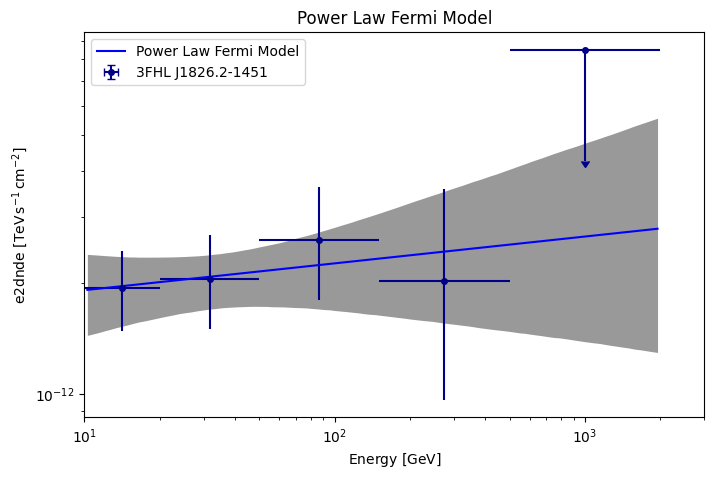

Índice en HESS J1826-148: 56
Dataset usado: HESS J1826-148
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.2406e+00 7.395e-02
amplitude 1.1068e-12 8.430e-14
reference 1.0000e+00 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


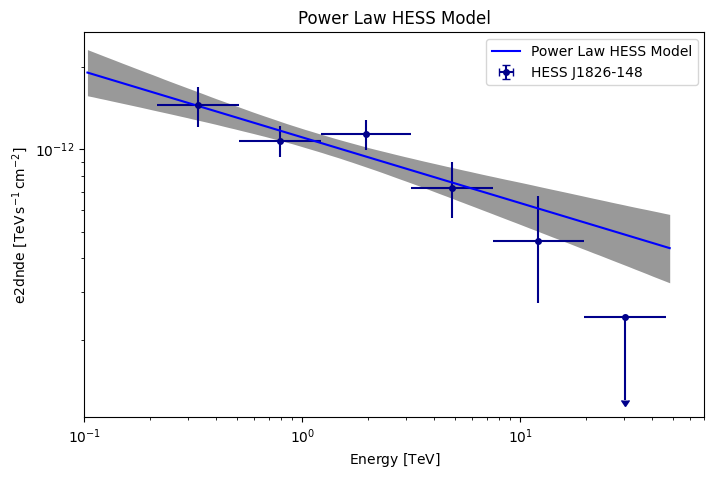

Índice en HESS J1826-148: 56
Dataset usado: HESS J1826-148
Índice en 3FHL J1826.2-1451: 1222
Dataset usado: 3FHL J1826.2-1451
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.1798e+00 3.499e-02
amplitude 4.8975e-12 3.379e-13
reference 5.0000e+02 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/maps/region/ndmap.py:154: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(
/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


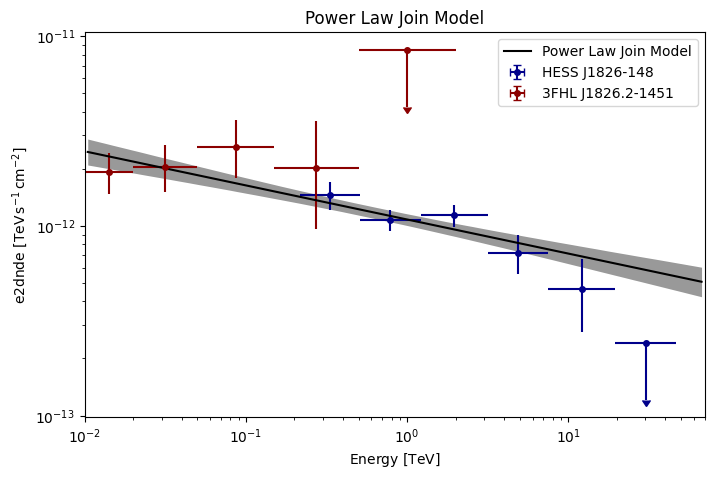

In [5]:
# ============================
# Ajuste Fermi
# ============================

fermi_name = ["3FHL J1826.2-1451"]   # Debe ser lista
fermi_model_name = "Power Law Fermi Model"

# Ajustar modelo para Fermi
fermi_sky_model, fds, fermi_sky_model_res = fix_model_given_catalog(
    catalogs=[fermi_cat],
    catNames=fermi_name,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",   # Unidad correcta para Fermi
    refUnits="100 GeV",
    modelName=fermi_model_name
)

# Pintar la gráfica para Fermi
showGraph(
    model=fermi_sky_model,
    fds=fds[0],
    ebounds=[10, 2000] * u.GeV,
    xLimits=[10, 3000] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=fermi_model_name
)



# ============================
# Ajuste H.E.S.S.
# ============================

hess_name = ["HESS J1826-148"]   # También debe ser lista
hess_model_name = "Power Law HESS Model"

# Ajustar modelo para HESS
hess_sky_model, hds, hess_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat],
    catNames=hess_name,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    modelName=hess_model_name
)

# Pintar la gráfica para HESS
showGraph(
    model=hess_sky_model,
    fds=hds[0],
    ebounds=[0.1, 50] * u.TeV,
    xLimits=[100, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=hess_model_name
)

# ============================
# Ajuste conjunto Fermi + HESS
# ============================

join_names = ["HESS J1826-148", "3FHL J1826.2-1451"]
join_model_name = "Power Law Join Model"

join_sky_model, join_ds, join_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat, fermi_cat],
    catNames=join_names,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",   # coherente con refUnits
    refUnits="500 GeV",                # pivot intermedio
    modelName=join_model_name
)


# ============================
# Gráfica conjunta
# ============================

showGraph_multi(
    model=join_sky_model,
    datasets=join_ds,                # <-- aquí van Fermi + HESS juntos
    ebounds=[10, 7e4] * u.GeV,       # <-- Rango energético conjunto (10 GeV → 70 TeV)
    xLimits=[10, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=join_model_name
)


## 5.1.2. Tabla de resultados

In [6]:
# ============================
# TABLA DE RESULTADOS
# ============================

df_results = build_spectral_table(
    models=[fermi_sky_model, hess_sky_model, join_sky_model],
    ref_energies=["100 GeV", "1 TeV", "500 GeV"],
    labels=["Solo Fermi-LAT (GeV)", "Solo H.E.S.S. (TeV)", "Conjunto (Banda Ancha)"]
)

df_results

,Modelo / Ajuste,Energía de Ref.,Índice Espectral (Γ),Norm. (×1e-12 TeV cm⁻²s⁻¹)
0,Solo Fermi-LAT (GeV),100 GeV,1.93 ± 0.17,225.3461 ± 57.0728
1,Solo H.E.S.S. (TeV),1 TeV,2.24 ± 0.07,1.1068 ± 0.0843
2,Conjunto (Banda Ancha),500 GeV,2.18 ± 0.03,4.8975 ± 0.3379


## 5.1.3. Análisis de residuos

In [7]:
# ============================
# ANÁLISIS DE RESTOS
# ============================

analyzeRes(fermi_sky_model,
               fermi_sky_model_res,
               hess_sky_model,
               hess_sky_model_res,
               join_sky_model,
               join_sky_model_res)

,Métrica de Control,Valor Obtenido,Contexto / Contribución
0,Residuos Sector Fermi (GeV),0.2692,4.89% del residuo total (Domina el ajuste cuan...
1,Residuos Sector H.E.S.S. (TeV),2.8247,51.31% del residuo total (Aporte numérico mino...
2,Suma Total de Residuos (S),5.5053,Métrica global de desviación absoluta
3,Índice Espectral (Γ) Solo Fermi,1.93,Espectro duro (Inyección eficiente de partículas)
4,Índice Espectral (Γ) Solo H.E.S.S.,2.24,Espectro blando (Escape o enfriamiento a altas...
5,Índice Espectral (Γ) Ajuste Conjunto,2.18,Pendiente ponderada (Sesgada hacia el régimen ...


## 5.2. PWN



Índice en 3FHL J1303.0-6312e: 835
Dataset usado: 3FHL J1303.0-6312e
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 1.8430e+00 8.662e-02
amplitude 3.7034e-10 5.893e-11
reference 1.0000e+02 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


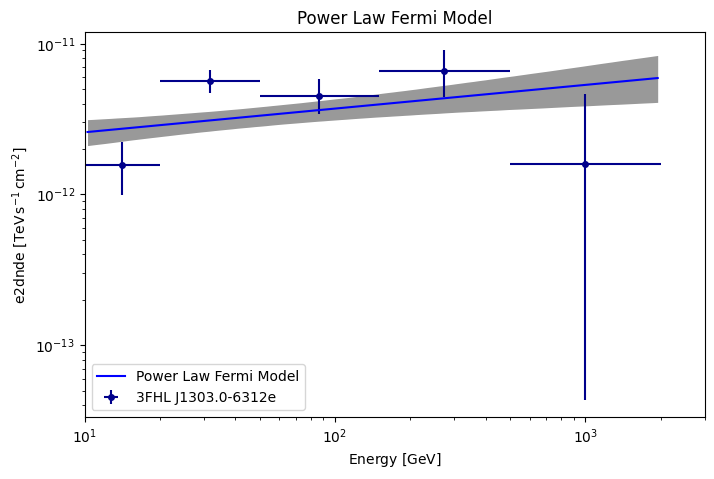

Índice en HESS J1303-631: 8
Dataset usado: HESS J1303-631
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.3430e+00 2.101e-02
amplitude 6.5472e-12 1.898e-13
reference 1.0000e+00 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


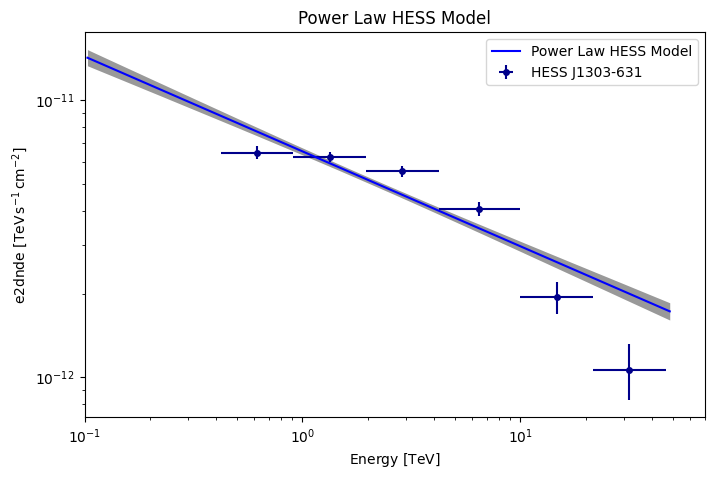

Índice en HESS J1303-631: 8
Dataset usado: HESS J1303-631
Índice en 3FHL J1303.0-6312e: 835
Dataset usado: 3FHL J1303.0-6312e
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.1001e+00 9.971e-03
amplitude 1.9148e-11 5.713e-13
reference 5.0000e+02 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/maps/region/ndmap.py:154: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(
/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


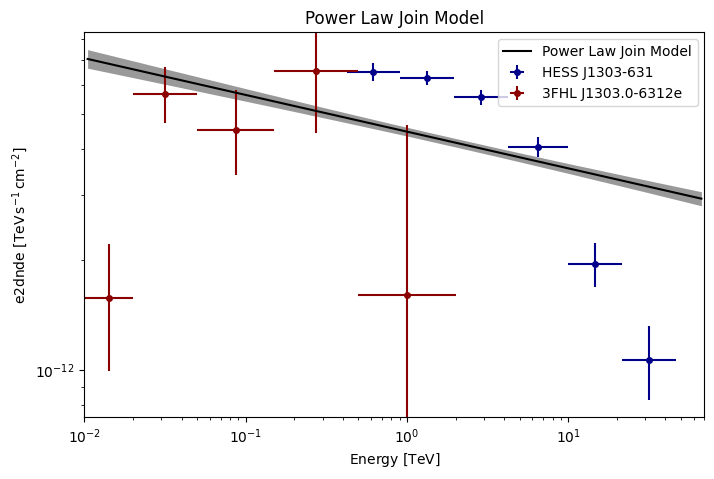

In [8]:
# ============================
# Ajuste Fermi
# ============================

fermi_name = ["3FHL J1303.0-6312e"]   # Debe ser lista
fermi_model_name = "Power Law Fermi Model"

# Ajustar modelo para Fermi
fermi_sky_model, fds, fermi_sky_model_res = fix_model_given_catalog(
    catalogs=[fermi_cat],
    catNames=fermi_name,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",   # Unidad correcta para Fermi
    refUnits="100 GeV",
    modelName=fermi_model_name
)

# Pintar la gráfica para Fermi
showGraph(
    model=fermi_sky_model,
    fds=fds[0],
    ebounds=[10, 2000] * u.GeV,
    xLimits=[10, 3000] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=fermi_model_name
)



# ============================
# Ajuste H.E.S.S.
# ============================

hess_name = ["HESS J1303-631"]   # También debe ser lista
hess_model_name = "Power Law HESS Model"

# Ajustar modelo para HESS
hess_sky_model, hds, hess_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat],
    catNames=hess_name,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    modelName=hess_model_name
)

# Pintar la gráfica para HESS
showGraph(
    model=hess_sky_model,
    fds=hds[0],
    ebounds=[0.1, 50] * u.TeV,
    xLimits=[100, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=hess_model_name
)

# ============================
# Ajuste conjunto Fermi + HESS
# ============================

join_names = ["HESS J1303-631", "3FHL J1303.0-6312e"]
join_model_name = "Power Law Join Model"

join_sky_model, join_ds, join_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat, fermi_cat],
    catNames=join_names,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",   # coherente con refUnits
    refUnits="500 GeV",                # pivot intermedio
    modelName=join_model_name
)


# ============================
# Gráfica conjunta
# ============================

showGraph_multi(
    model=join_sky_model,
    datasets=join_ds,                # <-- aquí van Fermi + HESS juntos
    ebounds=[10, 7e4] * u.GeV,       # <-- Rango energético conjunto (10 GeV → 70 TeV)
    xLimits=[10, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=join_model_name
)


## 5.2.2. Tabla de resultados



In [9]:
# ============================
# TABLA DE RESULTADOS
# ============================

df_results = build_spectral_table(
    models=[fermi_sky_model, hess_sky_model, join_sky_model],
    ref_energies=["100 GeV", "1 TeV", "500 GeV"],
    labels=["Solo Fermi-LAT (GeV)", "Solo H.E.S.S. (TeV)", "Conjunto (Banda Ancha)"]
)

df_results

,Modelo / Ajuste,Energía de Ref.,Índice Espectral (Γ),Norm. (×1e-12 TeV cm⁻²s⁻¹)
0,Solo Fermi-LAT (GeV),100 GeV,1.84 ± 0.09,370.3396 ± 58.9269
1,Solo H.E.S.S. (TeV),1 TeV,2.34 ± 0.02,6.5472 ± 0.1898
2,Conjunto (Banda Ancha),500 GeV,2.10 ± 0.01,19.1476 ± 0.5713


## 5.2.3. Análisis de residuos

In [10]:
# ============================
# ANÁLISIS DE RESTOS
# ============================

analyzeRes(fermi_sky_model,
               fermi_sky_model_res,
               hess_sky_model,
               hess_sky_model_res,
               join_sky_model,
               join_sky_model_res)

,Métrica de Control,Valor Obtenido,Contexto / Contribución
0,Residuos Sector Fermi (GeV),14.3850,4.89% del residuo total (Domina el ajuste cuan...
1,Residuos Sector H.E.S.S. (TeV),54.3693,18.50% del residuo total (Aporte numérico mino...
2,Suma Total de Residuos (S),293.9164,Métrica global de desviación absoluta
3,Índice Espectral (Γ) Solo Fermi,1.84,Espectro duro (Inyección eficiente de partículas)
4,Índice Espectral (Γ) Solo H.E.S.S.,2.34,Espectro blando (Escape o enfriamiento a altas...
5,Índice Espectral (Γ) Ajuste Conjunto,2.10,Pendiente ponderada (Sesgada hacia el régimen ...


## 5.3. Galactic Center

## 5.3.1. Ajuste Fermi, HESS y cjto

Índice en 3FHL J1745.6-2900: 1169
Dataset usado: 3FHL J1745.6-2900
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.7452e+00 1.175e-01
amplitude 4.3179e-10 8.632e-11
reference 1.0000e+02 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


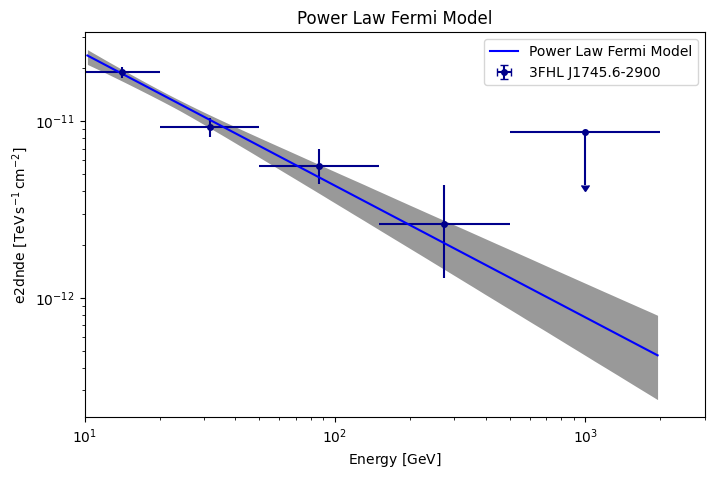

Índice en HESS J1745-290: 40
Dataset usado: HESS J1745-290
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.2949e+00 1.375e-02
amplitude 2.1540e-12 3.151e-14
reference 1.0000e+00 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


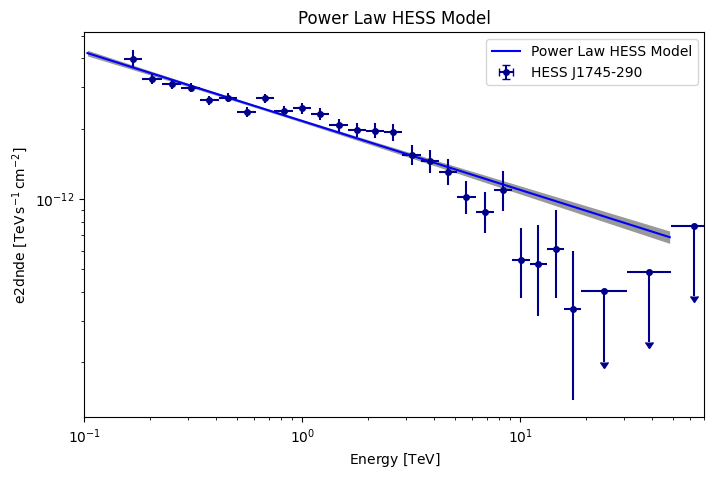

Índice en HESS J1745-290: 40
Dataset usado: HESS J1745-290
Índice en 3FHL J1745.6-2900: 1169
Dataset usado: 3FHL J1745.6-2900
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.3379e+00 1.422e-02
amplitude 1.0772e-11 1.420e-13
reference 5.0000e+02 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/maps/region/ndmap.py:154: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(
/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


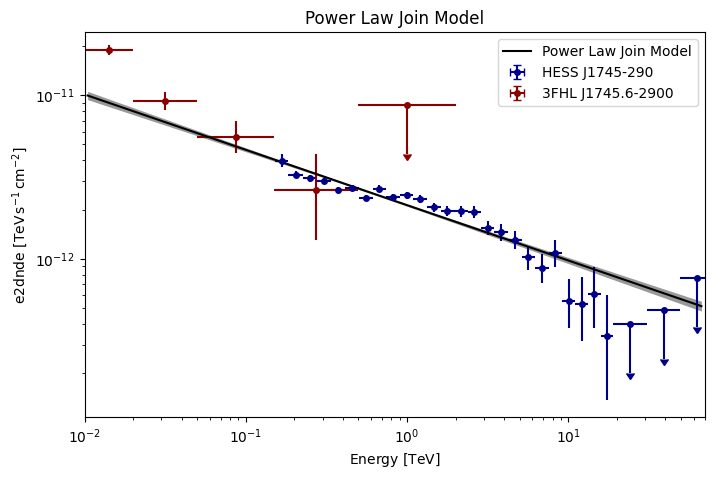

In [11]:
# ============================
# Ajuste Fermi
# ============================

fermi_name = ["3FHL J1745.6-2900"]   # Debe ser lista
fermi_model_name = "Power Law Fermi Model"

# Ajustar modelo para Fermi
fermi_sky_model, fds, fermi_sky_model_res = fix_model_given_catalog(
    catalogs=[fermi_cat],
    catNames=fermi_name,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",   # Unidad correcta para Fermi
    refUnits="100 GeV",
    modelName=fermi_model_name
)

# Pintar la gráfica para Fermi
showGraph(
    model=fermi_sky_model,
    fds=fds[0],
    ebounds=[10, 2000] * u.GeV,
    xLimits=[10, 3000] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=fermi_model_name
)



# ============================
# Ajuste H.E.S.S.
# ============================

hess_name = ["HESS J1745-290"]   # También debe ser lista
hess_model_name = "Power Law HESS Model"

# Ajustar modelo para HESS
hess_sky_model, hds, hess_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat],
    catNames=hess_name,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    modelName=hess_model_name
)

# Pintar la gráfica para HESS
showGraph(
    model=hess_sky_model,
    fds=hds[0],
    ebounds=[0.1, 50] * u.TeV,
    xLimits=[100, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=hess_model_name
)

# ============================
# Ajuste conjunto Fermi + HESS
# ============================

join_names = ["HESS J1745-290", "3FHL J1745.6-2900"]
join_model_name = "Power Law Join Model"

join_sky_model, join_ds, join_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat, fermi_cat],
    catNames=join_names,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",   # coherente con refUnits
    refUnits="500 GeV",                # pivot intermedio
    modelName=join_model_name
)


# ============================
# Gráfica conjunta
# ============================

showGraph_multi(
    model=join_sky_model,
    datasets=join_ds,                # <-- aquí van Fermi + HESS juntos
    ebounds=[10, 7e4] * u.GeV,       # <-- Rango energético conjunto (10 GeV → 70 TeV)
    xLimits=[10, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=join_model_name
)


## 5.3.2. Tabla de resultados

In [12]:
# ============================
# TABLA DE RESULTADOS
# ============================

df_results = build_spectral_table(
    models=[fermi_sky_model, hess_sky_model, join_sky_model],
    ref_energies=["100 GeV", "1 TeV", "500 GeV"],
    labels=["Solo Fermi-LAT (GeV)", "Solo H.E.S.S. (TeV)", "Conjunto (Banda Ancha)"]
)

df_results

,Modelo / Ajuste,Energía de Ref.,Índice Espectral (Γ),Norm. (×1e-12 TeV cm⁻²s⁻¹)
0,Solo Fermi-LAT (GeV),100 GeV,2.75 ± 0.12,431.7907 ± 86.3201
1,Solo H.E.S.S. (TeV),1 TeV,2.29 ± 0.01,2.1540 ± 0.0315
2,Conjunto (Banda Ancha),500 GeV,2.34 ± 0.01,10.7724 ± 0.1420


## 5.3.3. Análisis de residuos



In [13]:
# ============================
# ANÁLISIS DE RESTOS
# ============================

analyzeRes(fermi_sky_model,
               fermi_sky_model_res,
               hess_sky_model,
               hess_sky_model_res,
               join_sky_model,
               join_sky_model_res)

,Métrica de Control,Valor Obtenido,Contexto / Contribución
0,Residuos Sector Fermi (GeV),1.2557,0.96% del residuo total (Domina el ajuste cuan...
1,Residuos Sector H.E.S.S. (TeV),62.9163,48.26% del residuo total (Aporte numérico mino...
2,Suma Total de Residuos (S),130.3734,Métrica global de desviación absoluta
3,Índice Espectral (Γ) Solo Fermi,2.75,Espectro duro (Inyección eficiente de partículas)
4,Índice Espectral (Γ) Solo H.E.S.S.,2.29,Espectro blando (Escape o enfriamiento a altas...
5,Índice Espectral (Γ) Ajuste Conjunto,2.34,Pendiente ponderada (Sesgada hacia el régimen ...
